In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import re
import nltk
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')

# Set styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

Libraries imported
PyTorch version: 2.11.0+cpu
CUDA available: False


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Adhiraj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Adhiraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Adhiraj\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [10]:
from pathlib import Path

# Create project directory
project_dir = Path(r'C:/Python/ML Intro/Projects/Sentiment Analysis')
project_dir.mkdir(parents=True, exist_ok=True)

# Create subdirectories
dirs = ['data', 'models', 'results/plots', 'results/metrics', 'notebooks']
for d in dirs:
    (project_dir / d).mkdir(parents=True, exist_ok=True)

print(f" Project structure created:")
print(f"   {project_dir}/")
for d in dirs:
    print(f"   ├── {d}/")

 Project structure created:
   C:\Python\ML Intro\Projects\Sentiment Analysis/
   ├── data/
   ├── models/
   ├── results/plots/
   ├── results/metrics/
   ├── notebooks/


In [11]:
from datasets import load_dataset
import pandas as pd

print("Loading Amazon Product Reviews Dataset...")
print("=" * 70)

# Load dataset from Hugging Face
dataset = load_dataset(
    "fancyzhx/amazon_polarity",
    split={
        'train': 'train[:10000]',
        'test': 'test[:2000]'
    }
)

# Convert to pandas DataFrame
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print("Dataset loaded!")

print("\nDataset Info:")
print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

print(f"\nColumns: {list(train_df.columns)}")

print("\nSample rows:")
print(train_df.head(3))

Loading Amazon Product Reviews Dataset...
Dataset loaded!

Dataset Info:
Train samples: 10000
Test samples: 2000

Columns: ['label', 'title', 'content']

Sample rows:
   label                                  title  \
0      1         Stuning even for the non-gamer   
1      1  The best soundtrack ever to anything.   
2      1                               Amazing!   

                                             content  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  


In [12]:
print("="*70)
print(" DATASET EXPLORATION")
print("="*70)

# Basic stats
print(f"\n Training Set Statistics:")
print(f"   Total samples: {len(train_df)}")
print(f"   Columns: {list(train_df.columns)}")
print(f"\n   Label distribution:")
print(train_df['label'].value_counts())
print(f"\n   Label mapping: 0 = Negative, 1 = Positive")

# Check for missing values
print(f"\n Missing Values:")
print(train_df.isnull().sum())

# Text length statistics
train_df['text_length'] = train_df['content'].str.len()
train_df['word_count'] = train_df['content'].str.split().str.len()

print(f"\n Text Length Statistics:")
print(f"   Average characters: {train_df['text_length'].mean():.0f}")
print(f"   Average words: {train_df['word_count'].mean():.0f}")
print(f"   Max characters: {train_df['text_length'].max()}")
print(f"   Min characters: {train_df['text_length'].min()}")

# Sample reviews
print(f"\n Sample Reviews:")
print("\n[POSITIVE REVIEW]:")
print(train_df[train_df['label'] == 1]['content'].iloc[0][:200])
print("\n[NEGATIVE REVIEW]:")
print(train_df[train_df['label'] == 0]['content'].iloc[0][:200])

 DATASET EXPLORATION

 Training Set Statistics:
   Total samples: 10000
   Columns: ['label', 'title', 'content']

   Label distribution:
label
0    5097
1    4903
Name: count, dtype: int64

   Label mapping: 0 = Negative, 1 = Positive

 Missing Values:
label      0
title      0
content    0
dtype: int64

 Text Length Statistics:
   Average characters: 412
   Average words: 75
   Max characters: 1002
   Min characters: 55

 Sample Reviews:

[POSITIVE REVIEW]:
This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I

[NEGATIVE REVIEW]:
This is a self-published book, and if you want to know why--read a few paragraphs! Those 5 star reviews must have been written by Ms. Haddon's family and friends--or perhaps, by herself! I can't imagi


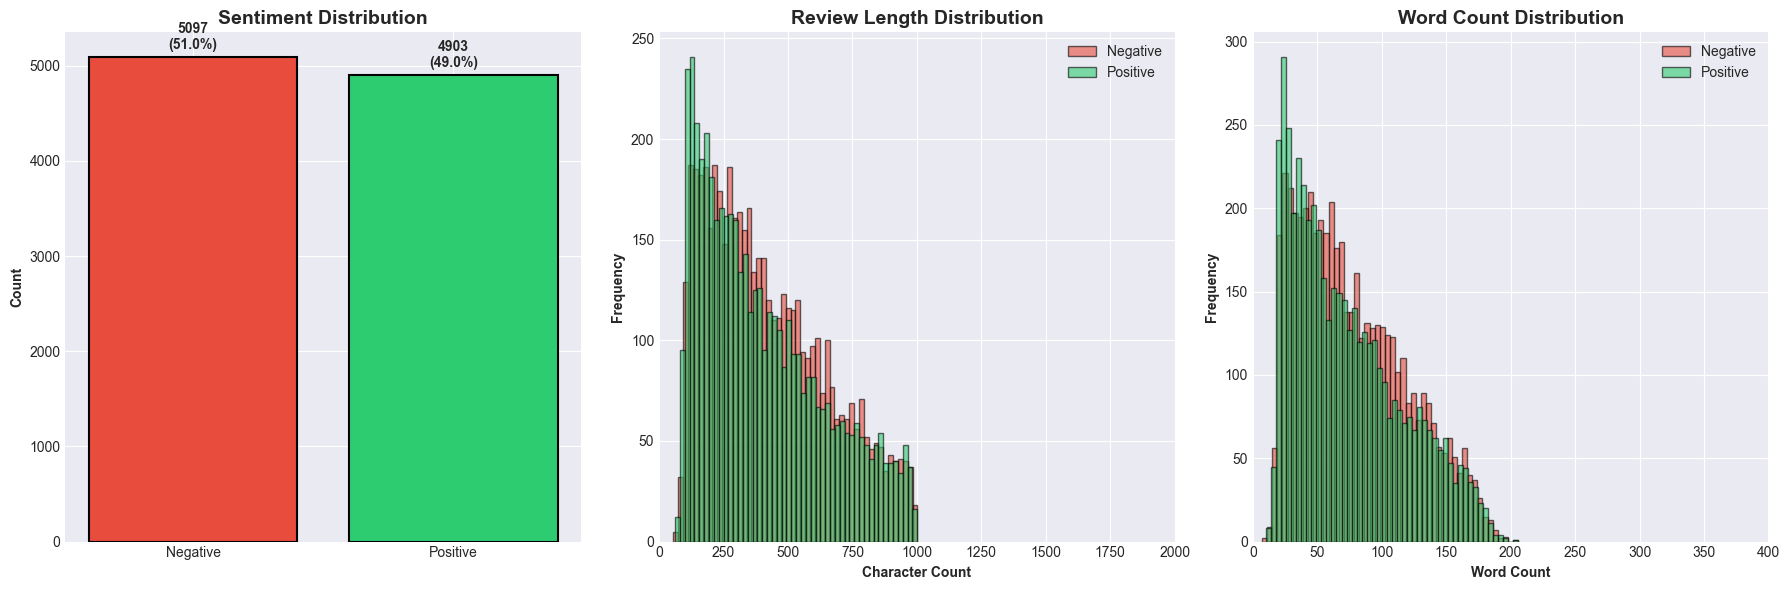

 Plot saved: C:\Python\ML Intro\Projects\Sentiment Analysis\results\plots\class_distribution.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Class distribution
ax1 = axes[0]
label_counts = train_df['label'].value_counts()
colors = ['#e74c3c', '#2ecc71']
bars = ax1.bar(['Negative', 'Positive'], label_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Sentiment Distribution', fontweight='bold', fontsize=14)
ax1.set_ylabel('Count', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{int(height)}\n({height/len(train_df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

# 2. Text length distribution
ax2 = axes[1]
train_df[train_df['label'] == 0]['text_length'].hist(
    ax=ax2, bins=50, alpha=0.6, color='#e74c3c', label='Negative', edgecolor='black')
train_df[train_df['label'] == 1]['text_length'].hist(
    ax=ax2, bins=50, alpha=0.6, color='#2ecc71', label='Positive', edgecolor='black')
ax2.set_title('Review Length Distribution', fontweight='bold', fontsize=14)
ax2.set_xlabel('Character Count', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.legend()
ax2.set_xlim(0, 2000)

# 3. Word count distribution
ax3 = axes[2]
train_df[train_df['label'] == 0]['word_count'].hist(
    ax=ax3, bins=50, alpha=0.6, color='#e74c3c', label='Negative', edgecolor='black')
train_df[train_df['label'] == 1]['word_count'].hist(
    ax=ax3, bins=50, alpha=0.6, color='#2ecc71', label='Positive', edgecolor='black')
ax3.set_title('Word Count Distribution', fontweight='bold', fontsize=14)
ax3.set_xlabel('Word Count', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.legend()
ax3.set_xlim(0, 400)

plt.tight_layout()
save_path = str(project_dir / 'results' / 'plots' / 'class_distribution.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f" Plot saved: {save_path}")

In [15]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Get stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Clean and preprocess text
    """
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove special characters (keep letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def get_word_frequency(texts, top_n=30):
    """
    Get most common words in text
    """
    all_words = []
    
    for text in texts:
        tokens = word_tokenize(text)
        words = [w for w in tokens if w not in stop_words and len(w) > 2]
        all_words.extend(words)
    
    return Counter(all_words).most_common(top_n)


# Apply preprocessing
print(" Preprocessing text...")
train_df['cleaned_text'] = train_df['content'].apply(preprocess_text)
test_df['cleaned_text'] = test_df['content'].apply(preprocess_text)

print(f" Preprocessing complete!")
print(f"\n Sample original text:")
print(train_df['content'].iloc[0][:200])
print(f"\n Sample cleaned text:")
print(train_df['cleaned_text'].iloc[0][:200])

# Get word frequencies
print("\n Getting word frequencies...")
pos_words = get_word_frequency(
    train_df[train_df['label'] == 1]['cleaned_text'],
    top_n=20
)
neg_words = get_word_frequency(
    train_df[train_df['label'] == 0]['cleaned_text'],
    top_n=20
)

print("\n Word frequencies calculated")

 Preprocessing text...
 Preprocessing complete!

 Sample original text:
This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I

 Sample cleaned text:
this sound track was beautiful it paints the senery in your mind so well i would recomend it even to people who hate vid game music i have played the game chrono cross but out of all of the games i ha

 Getting word frequencies...

 Word frequencies calculated


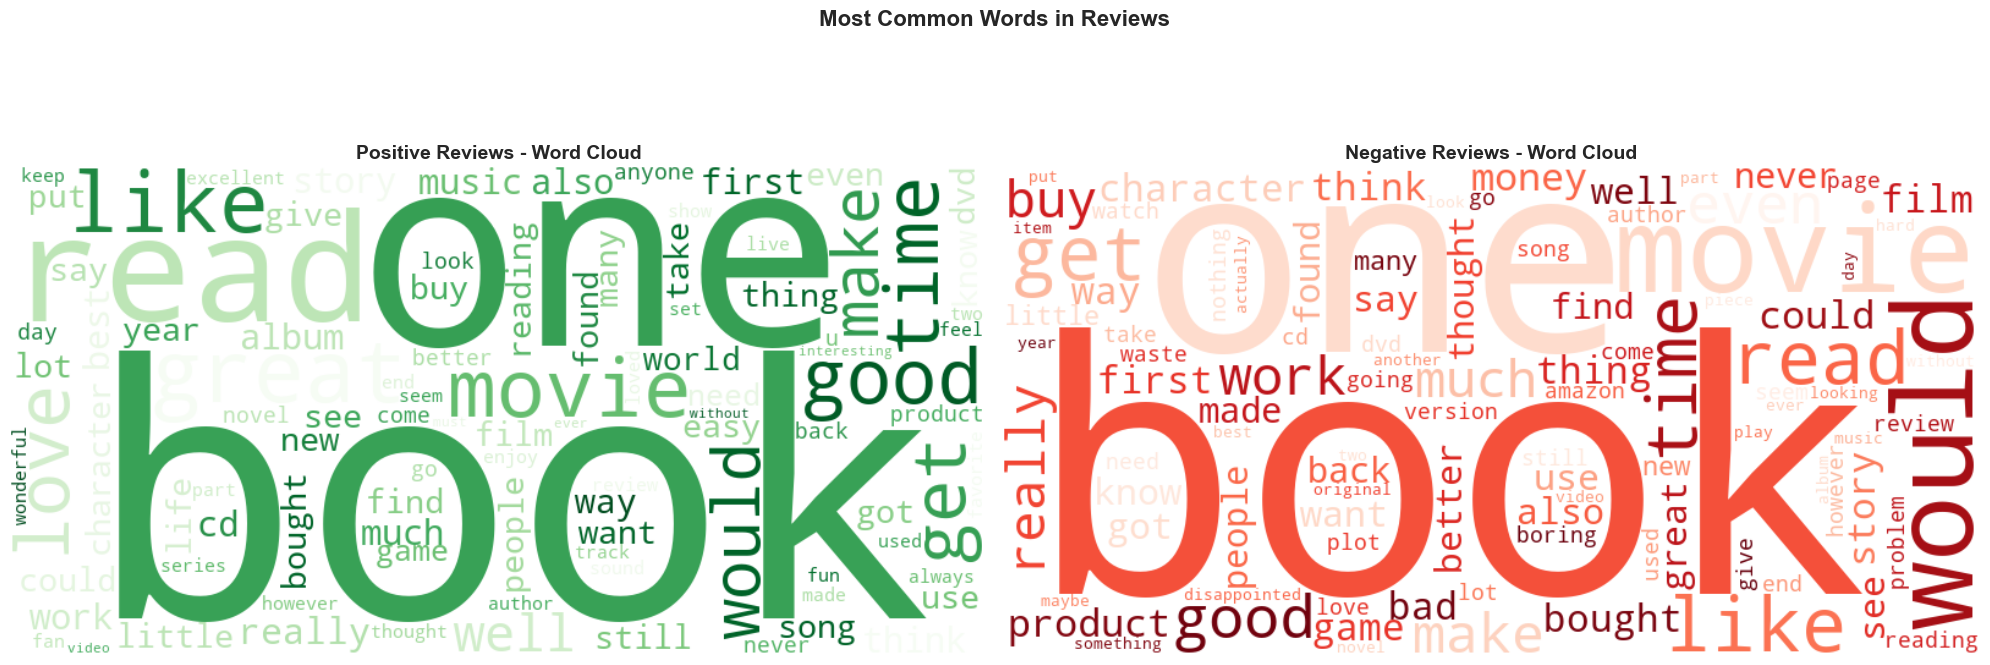

 Word clouds saved: C:\Python\ML Intro\Projects\Sentiment Analysis\results\plots\wordclouds.png


In [16]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Positive reviews word cloud
pos_text = ' '.join(train_df[train_df['label'] == 1]['cleaned_text'])
pos_wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100,
    stopwords=stop_words
).generate(pos_text)

axes[0].imshow(pos_wordcloud, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Word Cloud', fontweight='bold', fontsize=14)
axes[0].axis('off')

# Negative reviews word cloud
neg_text = ' '.join(train_df[train_df['label'] == 0]['cleaned_text'])
neg_wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    stopwords=stop_words
).generate(neg_text)

axes[1].imshow(neg_wordcloud, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Word Cloud', fontweight='bold', fontsize=14)
axes[1].axis('off')

plt.suptitle('Most Common Words in Reviews', fontsize=16, fontweight='bold')
plt.tight_layout()
save_path = str(project_dir / 'results' / 'plots' / 'wordclouds.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f" Word clouds saved: {save_path}")

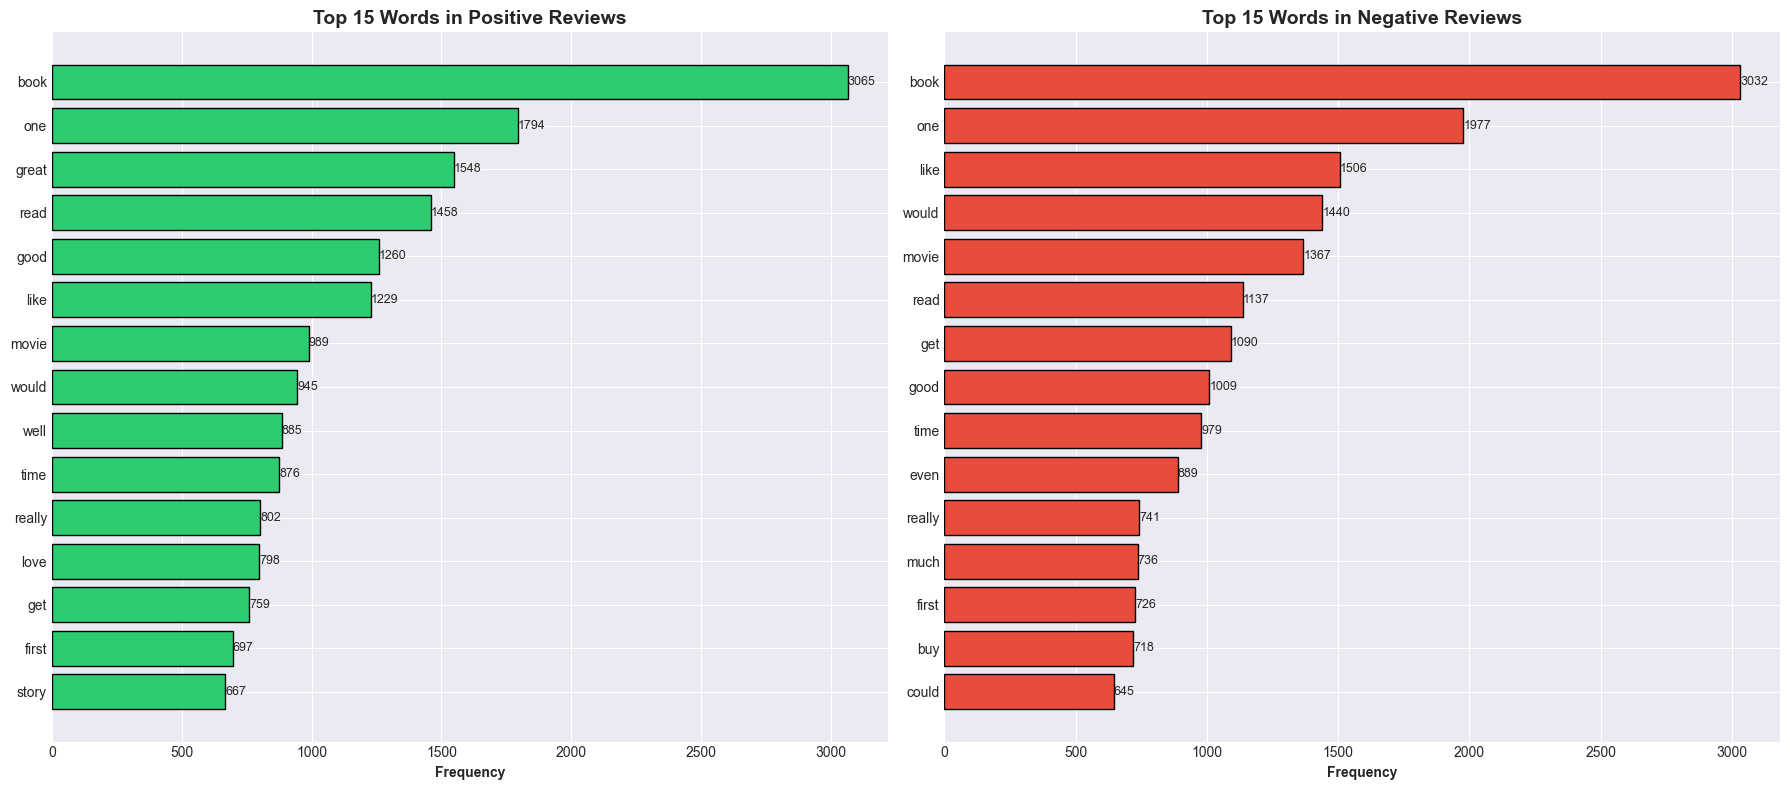

✅ Top words plot saved: C:\Python\ML Intro\Projects\Sentiment Analysis\results\plots\top_words.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Positive top words
pos_words_df = pd.DataFrame(pos_words, columns=['Word', 'Count'])
ax1 = axes[0]
bars = ax1.barh(pos_words_df['Word'][:15], pos_words_df['Count'][:15],
                color='#2ecc71', edgecolor='black')
ax1.set_title('Top 15 Words in Positive Reviews', fontweight='bold', fontsize=14)
ax1.set_xlabel('Frequency', fontweight='bold')
ax1.invert_yaxis()
for bar in bars:
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2., f'{int(width)}',
            ha='left', va='center', fontsize=9)

# Negative top words
neg_words_df = pd.DataFrame(neg_words, columns=['Word', 'Count'])
ax2 = axes[1]
bars = ax2.barh(neg_words_df['Word'][:15], neg_words_df['Count'][:15],
                color='#e74c3c', edgecolor='black')
ax2.set_title('Top 15 Words in Negative Reviews', fontweight='bold', fontsize=14)
ax2.set_xlabel('Frequency', fontweight='bold')
ax2.invert_yaxis()
for bar in bars:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2., f'{int(width)}',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
save_path = str(project_dir / 'results' / 'plots' / 'top_words.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Top words plot saved: {save_path}")

In [18]:
from textblob import TextBlob
from sklearn.metrics import accuracy_score, classification_report

print("📊 Running baseline sentiment analysis with TextBlob...")

def textblob_sentiment(text):
    """Get sentiment using TextBlob (rule-based)"""
    analysis = TextBlob(text)
    return 1 if analysis.sentiment.polarity > 0 else 0

# Apply to test set
print("🔄 Running predictions on test set...")
test_df['textblob_pred'] = test_df['cleaned_text'].apply(textblob_sentiment)

# Evaluate
accuracy = accuracy_score(test_df['label'], test_df['textblob_pred'])

print("\n" + "="*70)
print("📊 TEXTBLOB BASELINE RESULTS")
print("="*70)
print(f"\nAccuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(
    test_df['label'],
    test_df['textblob_pred'],
    target_names=['Negative', 'Positive'],
    digits=4
))
print("="*70)
print("\n💡 We'll beat this with BERT in Week 2!")

📊 Running baseline sentiment analysis with TextBlob...
🔄 Running predictions on test set...

📊 TEXTBLOB BASELINE RESULTS

Accuracy: 67.80%

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8326    0.4067    0.5465       954
    Positive     0.6310    0.9254    0.7504      1046

    accuracy                         0.6780      2000
   macro avg     0.7318    0.6661    0.6484      2000
weighted avg     0.7272    0.6780    0.6531      2000


💡 We'll beat this with BERT in Week 2!


In [20]:
print("\n" + "="*70)
print("🎉 WEEK 1 - DATA PREPARATION COMPLETE!")
print("="*70)

print("\n✅ Completed Tasks:")
print("   ✓ Libraries installed and imported")
print("   ✓ Amazon Reviews dataset loaded")
print("   ✓ Data explored and analyzed")
print("   ✓ Text preprocessing complete")
print("   ✓ Word clouds generated")
print("   ✓ Baseline model (TextBlob) evaluated")
print("   ✓ Preprocessed data saved")

print("\n📊 Dataset Summary:")
print(f"   Training samples: {len(train_df)}")
print(f"   Test samples: {len(test_df)}")
print(f"   Positive reviews: {(train_df['label'] == 1).sum()}")
print(f"   Negative reviews: {(train_df['label'] == 0).sum()}")
print(f"   Average review length: {train_df['word_count'].mean():.0f} words")

print(f"\n📊 TextBlob Baseline:")
print(f"   Accuracy: {accuracy*100:.2f}%")
print(f"\n🎯 Goal for Week 2:")
print(f"   Beat TextBlob with BERT (target: >90% accuracy)")

print("\n📁 Files Created:")
print(f"   • data/train_processed.csv")
print(f"   • data/test_processed.csv")
print(f"   • config.json")
print(f"   • results/plots/class_distribution.png")
print(f"   • results/plots/wordclouds.png")
print(f"   • results/plots/top_words.png")

print("\n🚀 Next Steps (Week 2):")
print("   1. Load DistilBERT model")
print("   2. Tokenize text data")
print("   3. Build classification model")
print("   4. Train with fine-tuning")
print("   5. Evaluate performance")
print("="*70)


🎉 WEEK 1 - DATA PREPARATION COMPLETE!

✅ Completed Tasks:
   ✓ Libraries installed and imported
   ✓ Amazon Reviews dataset loaded
   ✓ Data explored and analyzed
   ✓ Text preprocessing complete
   ✓ Word clouds generated
   ✓ Baseline model (TextBlob) evaluated
   ✓ Preprocessed data saved

📊 Dataset Summary:
   Training samples: 10000
   Test samples: 2000
   Positive reviews: 4903
   Negative reviews: 5097
   Average review length: 75 words

📊 TextBlob Baseline:
   Accuracy: 67.80%

🎯 Goal for Week 2:
   Beat TextBlob with BERT (target: >90% accuracy)

📁 Files Created:
   • data/train_processed.csv
   • data/test_processed.csv
   • config.json
   • results/plots/class_distribution.png
   • results/plots/wordclouds.png
   • results/plots/top_words.png

🚀 Next Steps (Week 2):
   1. Load DistilBERT model
   2. Tokenize text data
   3. Build classification model
   4. Train with fine-tuning
   5. Evaluate performance
